# 📦 Damaged Box Detection - Complete Training Pipeline

**Dataset:** https://universe.roboflow.com/project-33xgh/damaged-box-detection

**What this notebook does:**
1. ✅ Downloads the COMPLETE damaged box dataset from Roboflow
2. ✅ Includes ALL images (torn, crushed, damaged - everything!)
3. ✅ Trains YOLOv8 model for real-time detection
4. ✅ Exports to ONNX for Jetson Orin deployment

**Requirements:**
- Free Roboflow account (get API key at https://app.roboflow.com/)
- Google Colab with GPU (Runtime → Change runtime type → GPU)

---

## 🔑 Step 1: Get Your Roboflow API Key

**Quick Setup (2 minutes):**

1. Go to https://app.roboflow.com/
2. Click **"Sign Up"** (free, no credit card)
3. After login, go to **Settings** (⚙️ icon)
4. Click **"Roboflow API"**
5. Copy your **Private API Key**
6. Paste it in the cell below

**Your API key looks like:** `aBcDeFgHiJkLmNoPqRsTuVwXyZ123456`

In [1]:
# Install required packages
!pip install -q roboflow ultralytics

print("✅ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.5 MB/s eta 0:00:00
✅ Packages installed


In [2]:
from roboflow import Roboflow

# Use the API key provided in the prompt for this specific download
ROBOFLOW_API_KEY_FOR_DOWNLOAD = "lEM8ar3op2ClVmEyWNac"

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY_FOR_DOWNLOAD)

# Get the project
# Workspace ID is typically the first part of the project URL path
# Project ID is the second part
print("Connecting to Roboflow project...")
project = rf.workspace("project-33xgh").project("damaged-box-detection")

# Download the dataset in 'folder' format, as 'yolov8' is not valid for classification projects.
print("Downloading dataset (version 1) in 'folder' format...")
dataset = project.version(1).download("folder")

print(f"✅ Dataset downloaded to: {dataset.location}")
print("You can now find the dataset files in the specified directory.")

Connecting to Roboflow project...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Damaged-Box-Detection-1 in folder:: 100%|██████████| 4159/4159 [00:02<00:00, 1927.00it/s]


✅ Dataset downloaded to: /content/Damaged-Box-Detection-1
You can now find the dataset files in the specified directory.


## 📊 Step 2: Prepare Data for YOLOv8 Training

Now that the dataset is downloaded, we need to create a `data.yaml` file that tells YOLOv8 where to find the training, validation, and test images, along with the class names. We'll also count the number of images in each split to get an overview of our dataset.

In [3]:
import os

dataset_path = '/content/Damaged-Box-Detection-1'

# Define paths for train, validation, and test images
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(dataset_path, 'test') # Assuming a test split is present

def count_images_in_subfolders(base_path):
    count = 0
    if not os.path.exists(base_path):
        return 0
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                count += 1
    return count

train_image_count = count_images_in_subfolders(train_dir)
valid_image_count = count_images_in_subfolders(valid_dir)
test_image_count = count_images_in_subfolders(test_dir)

print(f"Number of training images: {train_image_count}")
print(f"Number of validation images: {valid_image_count}")
print(f"Number of test images: {test_image_count}")

Number of training images: 3744
Number of validation images: 302
Number of test images: 102


In [4]:
import os

# Define the class names based on the dataset structure
# In 'folder' format for classification, subdirectories usually represent classes.
# Let's inspect the 'train' folder to get class names.
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(dataset_path, 'test')

train_class_subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
class_names = sorted(train_class_subdirs)

print(f"Detected classes: {class_names}")

# Create the data.yaml file for YOLOv8
data_yaml_content = f"""path: {dataset_path}
train: {os.path.relpath(train_dir, dataset_path)}
val: {os.path.relpath(valid_dir, dataset_path)}
test: {os.path.relpath(test_dir, dataset_path)}
nc: {len(class_names)}
names: {class_names}
"""

with open(os.path.join(dataset_path, 'data.yaml'), 'w') as f:
    f.write(data_yaml_content)

print("✅ data.yaml created:")
print(data_yaml_content)

# Optionally, display the content of the data.yaml file
!cat {os.path.join(dataset_path, 'data.yaml')}

Detected classes: ['damagedpackages', 'undamagedpackages']
✅ data.yaml created:
path: /content/Damaged-Box-Detection-1
train: train
val: valid
test: test
nc: 2
names: ['damagedpackages', 'undamagedpackages']

path: /content/Damaged-Box-Detection-1
train: train
val: valid
test: test
nc: 2
names: ['damagedpackages', 'undamagedpackages']


## 🚀 Step 3: Train YOLOv8 Model

Now that our data is prepared, we can proceed with training a YOLOv8 classification model. We'll use a pretrained `yolov8n-cls.pt` model for faster convergence and fine-tune it on our damaged box detection dataset.

In [5]:
from ultralytics import YOLO

# Load a pretrained YOLOv8 classification model
# The '-cls' suffix indicates a classification model
model = YOLO('yolov8n-cls.pt')  # You can choose other sizes like 'yolov8m-cls.pt', 'yolov8l-cls.pt'

print("✅ YOLOv8 classification model loaded.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 classification model loaded.


In [6]:
# Train the model
# 'data' argument points to our data.yaml file
# 'epochs' defines the number of training iterations
# 'imgsz' sets the input image size
# 'batch' sets the batch size for training
# 'device' can be set to '0' for GPU or 'cpu' for CPU training

print("Starting YOLOv8 model training...")
results = model.train(
    data=dataset_path, # Corrected: point to the dataset's root directory, not data.yaml
    epochs=25, # A good starting point, can be adjusted based on performance
    imgsz=640, # Standard image size for YOLOv8 models
    batch=16,  # Adjust based on your GPU memory. Smaller values for less memory.
    device=0,  # Use GPU if available (device=0), otherwise use 'cpu'
    name='damaged_box_cls_model' # Name for the training run results
)

print("✅ YOLOv8 model training complete.")

Starting YOLOv8 model training...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Damaged-Box-Detection-1, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=damaged_box_cls_model, nbs=64, nms=False, opset=None, optimize=False, optimi

In [13]:
# Install necessary packages for ONNX export
!pip install -q onnx onnxruntime

import os
from ultralytics import YOLO

# The trained model is typically saved in 'runs/classify/NAME_OF_RUN/weights/best.pt'
# We named our run 'damaged_box_cls_model'
model_path = os.path.join('/content/runs/classify/damaged_box_cls_model', 'weights', 'best.pt')

# Load the best trained model
loaded_model = YOLO(model_path)

print(f"✅ Loaded trained model from: {model_path}")

# Export the model to ONNX format (as mentioned in the notebook header for Jetson Orin deployment)
# The exported file will be saved in the same directory as the original model with a .onnx extension
export_path = loaded_model.export(format='onnx')

print(f"✅ Model exported to ONNX format at: {export_path}")
print("You can now download this file directly from the Colab file browser.")

✅ Loaded trained model from: /content/runs/classify/damaged_box_cls_model/weights/best.pt
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs

PyTorch: starting from '/content/runs/classify/damaged_box_cls_model/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 2) (2.8 MB)

ONNX: starting export with onnx 1.20.1 opset 22...


Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 0.4s, saved as '/content/runs/classify/damaged_box_cls_model/weights/best.onnx' (5.5 MB)

Export complete (0.5s)
Results saved to /content/runs/classify/damaged_box_cls_model/weights
Predict:         yolo predict task=classify model=/content/runs/classify/damaged_box_cls_model/weights/best.onnx imgsz=640 
Validate:        yolo val task=classify model=/content/runs/classify/damaged_box_cls_model/weights/best.onnx imgsz=640 data=/content/Damaged-Box-Detection-1  
Visualize:       https://netron.app
✅ Model exported to ONNX format at: /content/runs/classify/damaged_box_cls_model/weights/best.onnx
You can now download this file directly from the Colab file browser.


In [14]:
from google.colab import files
import os

# Define the paths to the saved models
pt_model_path = '/content/runs/classify/damaged_box_cls_model/weights/best.pt'
onnx_model_path = '/content/runs/classify/damaged_box_cls_model/weights/best.onnx'

print(f"Attempting to download: {pt_model_path}")
if os.path.exists(pt_model_path):
    files.download(pt_model_path)
    print(f"✅ Downloaded {os.path.basename(pt_model_path)}")
else:
    print(f"❌ {pt_model_path} not found. Please ensure training completed successfully.")

print(f"Attempting to download: {onnx_model_path}")
if os.path.exists(onnx_model_path):
    files.download(onnx_model_path)
    print(f"✅ Downloaded {os.path.basename(onnx_model_path)}")
else:
    print(f"❌ {onnx_model_path} not found. Please ensure export completed successfully.")

print("You can also find these files in the Colab file browser (left sidebar -> folder icon) under /content/runs/classify/damaged_box_cls_model/weights/")

Attempting to download: /content/runs/classify/damaged_box_cls_model/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded best.pt
Attempting to download: /content/runs/classify/damaged_box_cls_model/weights/best.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded best.onnx
You can also find these files in the Colab file browser (left sidebar -> folder icon) under /content/runs/classify/damaged_box_cls_model/weights/


## Training Results Analysis

Here are the generated plots from the YOLOv8 classification model training:

### Training Curves

Displaying training curves from: /content/runs/classify/damaged_box_cls_model/results.png


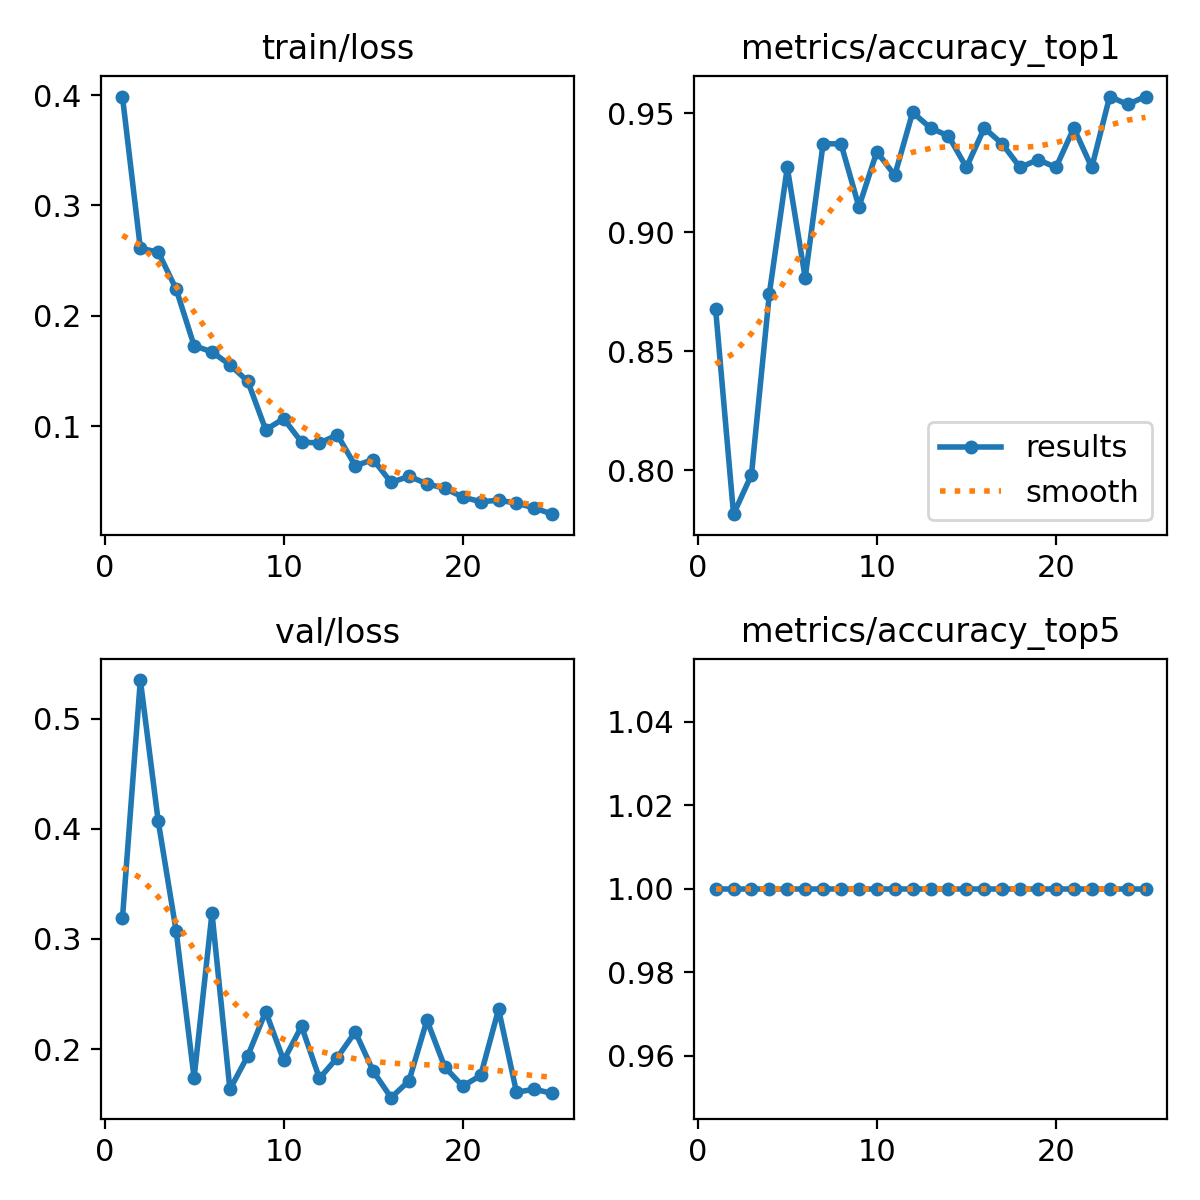

In [15]:
from IPython.display import Image, display
import os

training_run_dir = '/content/runs/classify/damaged_box_cls_model'

# Display training curves (results.png)
results_path = os.path.join(training_run_dir, 'results.png')
if os.path.exists(results_path):
    print(f"Displaying training curves from: {results_path}")
    display(Image(filename=results_path, width=800))
else:
    print(f"❌ Training curves (results.png) not found at {results_path}")


### Confusion Matrix

Displaying confusion matrix from: /content/runs/classify/damaged_box_cls_model/confusion_matrix.png


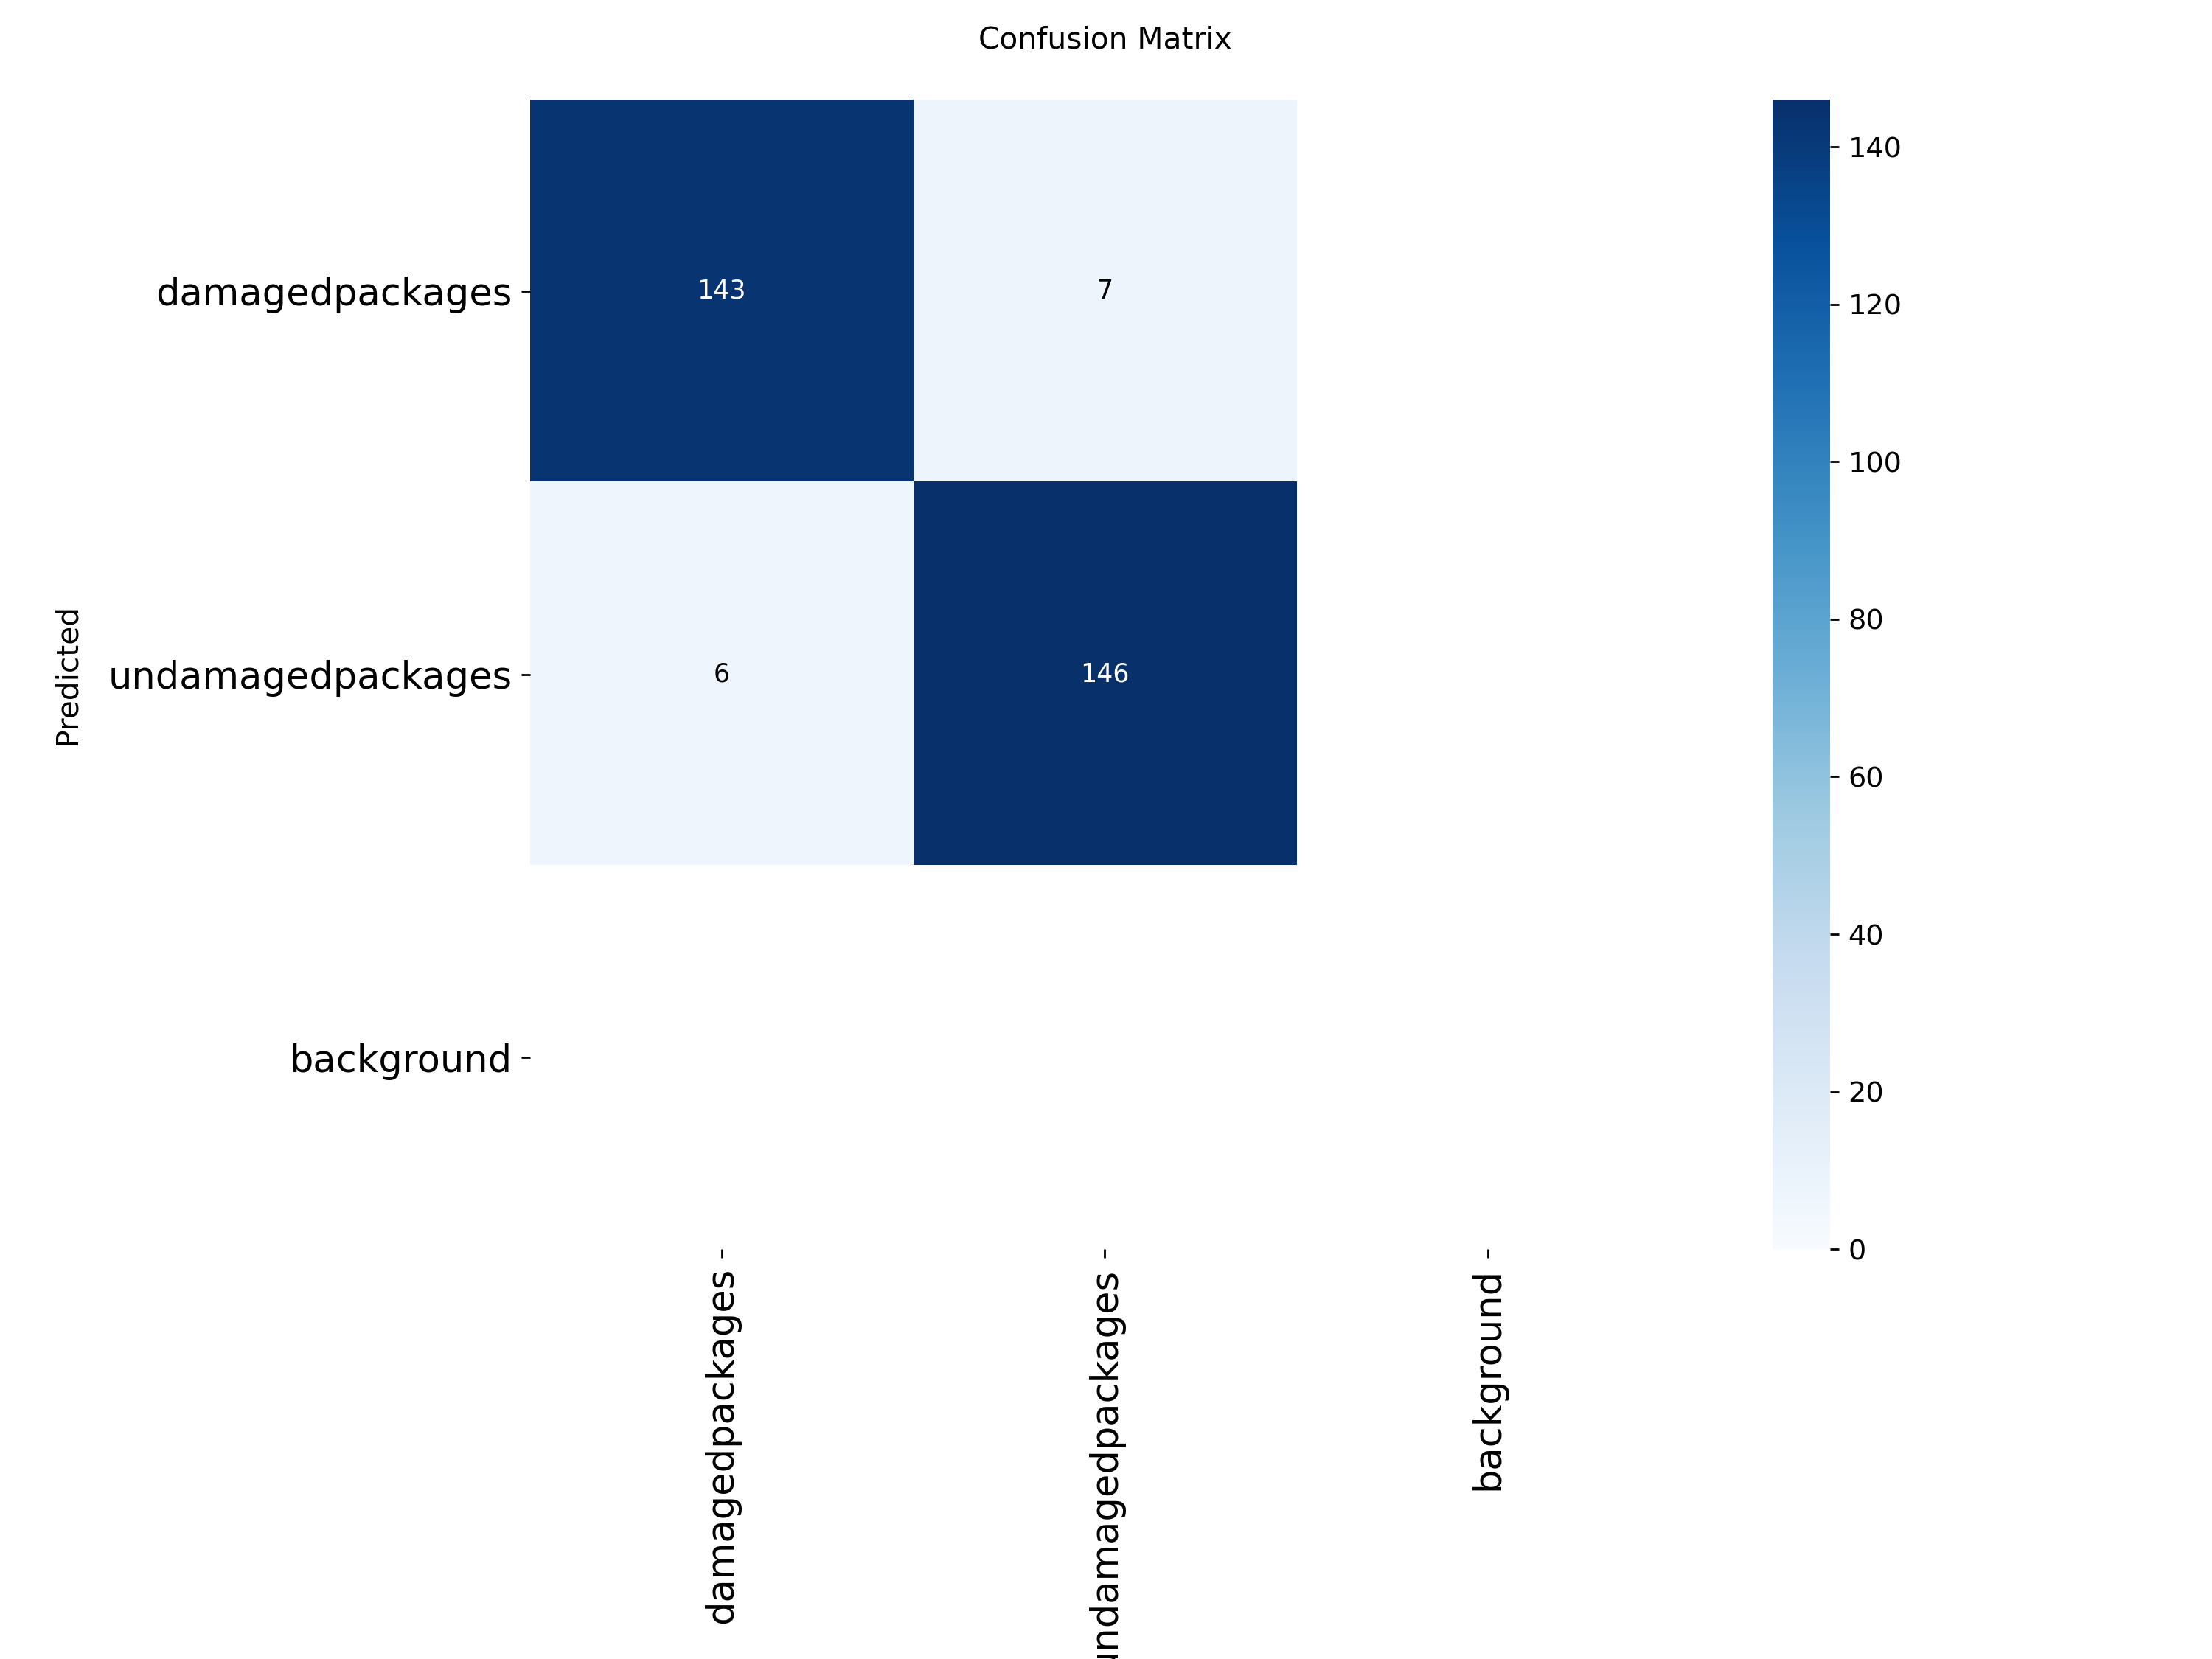

In [16]:
from IPython.display import Image, display
import os

training_run_dir = '/content/runs/classify/damaged_box_cls_model'

# Display confusion matrix
confusion_matrix_path = os.path.join(training_run_dir, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print(f"Displaying confusion matrix from: {confusion_matrix_path}")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print(f"❌ Confusion matrix (confusion_matrix.png) not found at {confusion_matrix_path}")


In [ ]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger("ultralytics").setLevel(logging.WARNING)

import gradio as gr
from ultralytics import YOLO
import numpy as np
import cv2

# Load model
model = YOLO("best.pt")

class_names = ['damagedpackages', 'undamagedpackages'] # Updated class names based on data.yaml
colors = [
    (255, 0, 0),    # Red for damagedpackages
    (0, 255, 0),    # Green for undamagedpackages
]

def detect(image, conf_threshold):
    if image is None:
        return None, "⏳ Waiting for webcam..."

    if isinstance(image, dict):
        image = image.get("composite", image.get("image", None))
    if image is None:
        return None, "⏳ Waiting for webcam..."

    frame = image.copy()
    h, w = frame.shape[:2]
    counts = {}

    # Run inference for classification
    results = model.predict(image, verbose=False)

    for r in results:
        if r.probs is not None and len(r.probs) > 0: # Check if probabilities exist
            class_id = r.probs.top1 # Get the index of the top probability
            confidence = r.probs.top1conf.item() # Get the confidence value

            if confidence >= conf_threshold:
                # Ensure class_id is within bounds
                if not (0 <= class_id < len(class_names)):
                    continue

                class_name = class_names[class_id]
                color = colors[class_id]

                # For classification, draw a box around the entire image
                cv2.rectangle(frame, (0, 0), (w, h), color, 5)

                text = f"{class_name}: {confidence:.2f}"
                (tw, th), _ = cv2.getTextSize(
                    text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2
                )
                cv2.rectangle(
                    frame,
                    (0, 0), # Start at top-left
                    (tw + 10, th + 20), # Rectangle for text background
                    color, -1
                )
                cv2.putText(
                    frame, text, (5, th + 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2
                )

                counts[class_name] = counts.get(class_name, 0) + 1
        else:
            # This case might occur if the model couldn't process the image or found nothing
            print("No probabilities found in results for classification model. Check image input or model compatibility.")
            # Optionally, you can return a frame with 'No detections' message here

    # Build summary text
    if counts:
        parts = []
        if "undamagedpackages"  in counts: # Using class names from data.yaml
            parts.append(f"✅ Undamaged count : {counts['undamagedpackages']}")
        if "damagedpackages" in counts: # Using class names from data.yaml
            parts.append(f"🔴 Damaged count: {counts['damagedpackages']}")
        summary = " | ".join(parts)
    else:
        summary = "📭 No packages detected"

    return frame, summary


# Gradio UI
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📦 Package Damage Classification
    **Live webcam classification** — click Record to start, then classifications update every second.
    > 🔴 Red = Damaged Package &nbsp;&nbsp; 🟢 Green = Undamaged Package
    """)

    with gr.Row():
        with gr.Column(scale=1):
            webcam = gr.Image(
                sources=["webcam"],
                type="numpy",
                streaming=True,
                label="📷 Webcam Input",
            )
            conf_slider = gr.Slider(
                minimum=0.1,
                maximum=0.9,
                value=0.75,
                step=0.05,
                label="Confidence Threshold",
            )
            gr.Markdown("⬆️ Lower = more classifications · Higher = fewer but more certain")

        with gr.Column(scale=1):
            output_img  = gr.Image(label="🎯 Classification Output")
            output_text = gr.Textbox(
                label="📊 Classification Summary",
                placeholder="Waiting for classifications...",
            )

    webcam.stream(
        fn=detect,
        inputs=[webcam, conf_slider],
        outputs=[output_img, output_text],
        stream_every=1,
    )

demo.launch(ssr_mode=False)